In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [11]:
# =====================================================
# RUTAS
# =====================================================

DATASET_PATH = Path("../dataset")
TRAIN_PATH = DATASET_PATH / "ORL_Limpio" / "Training"

RUTAS_X2 = {
    "Original": TRAIN_PATH / "s1",
    "LR x2": DATASET_PATH / "Degradacion" / "ORL_escala2" / "Training" / "s1",
    "CLAHE x2": DATASET_PATH / "Tecnica De mejora de imagen" / "ORL_CLAHE_x2" / "Training" / "s1",
    "SRCNN x2": DATASET_PATH / "Tecnica De mejora de imagen" / "ORL_SuperResolution_x2" / "Training" / "s1",
}

ETIQUETAS_X2 = [
    "Original",
    "LR (Escala ×2)",
    "CLAHE (Escala ×2)",
    "SRCNN (Escala ×2)"
]

RUTAS_X4 = {
    "Original": TRAIN_PATH / "s1",
    "LR x4": DATASET_PATH / "Degradacion" / "ORL_escala4" / "Training" / "s1",
    "CLAHE x4": DATASET_PATH / "Tecnica De mejora de imagen" / "ORL_CLAHE_x4" / "Training" / "s1",
    "SRCNN x4": DATASET_PATH / "Tecnica De mejora de imagen" / "ORL_SuperResolution_x4" / "Training" / "s1",
}

ETIQUETAS_X4 = [
    "Original",
    "LR (Escala ×4)",
    "CLAHE (Escala ×4)",
    "SRCNN (Escala ×4)"
]


In [12]:
# =====================================================
# ARCHIVOS
# =====================================================

archivos = sorted([
    f for f in os.listdir(RUTAS_X2["Original"])
    if f.lower().endswith(".pgm")
])

num_imgs = min(5, len(archivos))

print("Cantidad de imágenes:", len(archivos))
print("Mostrando:", num_imgs)


Cantidad de imágenes: 9
Mostrando: 5


In [15]:
def mostrar_comparacion(rutas, etiquetas, archivos, titulo):

    num_imgs = min(5, len(archivos))

    fig, axes = plt.subplots(
        nrows=len(rutas),
        ncols=num_imgs,
        figsize=(16, 10)
    )

    plt.subplots_adjust(
        left=0.18,
        top=0.92,
        bottom=0.04,
        right=0.98,
        hspace=0.12,
        wspace=0.05
    )

    for fila, ((nombre, ruta_base), etiqueta) in enumerate(
            zip(rutas.items(), etiquetas)):

        for col in range(num_imgs):

            archivo_original = archivos[col]
            nombre_base = Path(archivo_original).stem

            # Original está en .pgm; el resto en .png
            if nombre == "Original":
                archivo_actual = nombre_base + ".pgm"
            else:
                archivo_actual = nombre_base + ".png"

            ruta_img = ruta_base / archivo_actual

            img = cv2.imread(str(ruta_img), cv2.IMREAD_GRAYSCALE)

            if img is None:
                print("No se pudo leer:", ruta_img)
                continue

            ax = axes[fila, col]
            ax.imshow(img, cmap="gray")
            ax.axis("off")

            if fila == 0:
                ax.set_title(
                    f"Img {col+1}",
                    fontsize=11,
                    fontweight="bold"
                )

            if col == 0:
                ax.text(
                    -0.25,
                    0.5,
                    etiqueta,
                    fontsize=11,
                    fontweight="bold",
                    rotation=90,
                    ha="right",
                    va="center",
                    transform=ax.transAxes
                )

    plt.suptitle(
        titulo,
        fontsize=14,
        fontweight="bold"
    )

    plt.show()

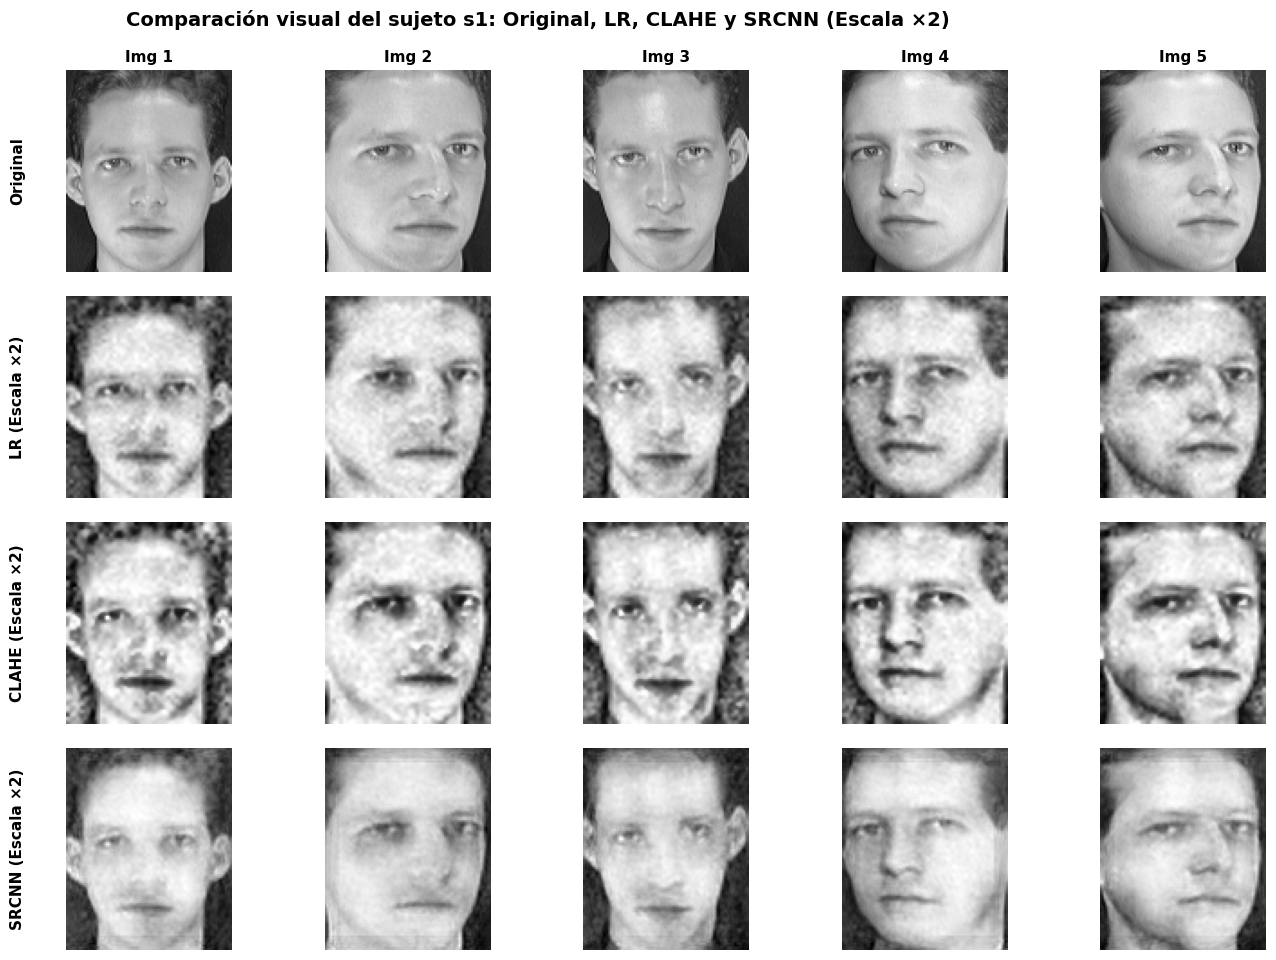

In [16]:
mostrar_comparacion(
    RUTAS_X2,
    ETIQUETAS_X2,
    archivos,
    "Comparación visual del sujeto s1: Original, LR, CLAHE y SRCNN (Escala ×2)"
)

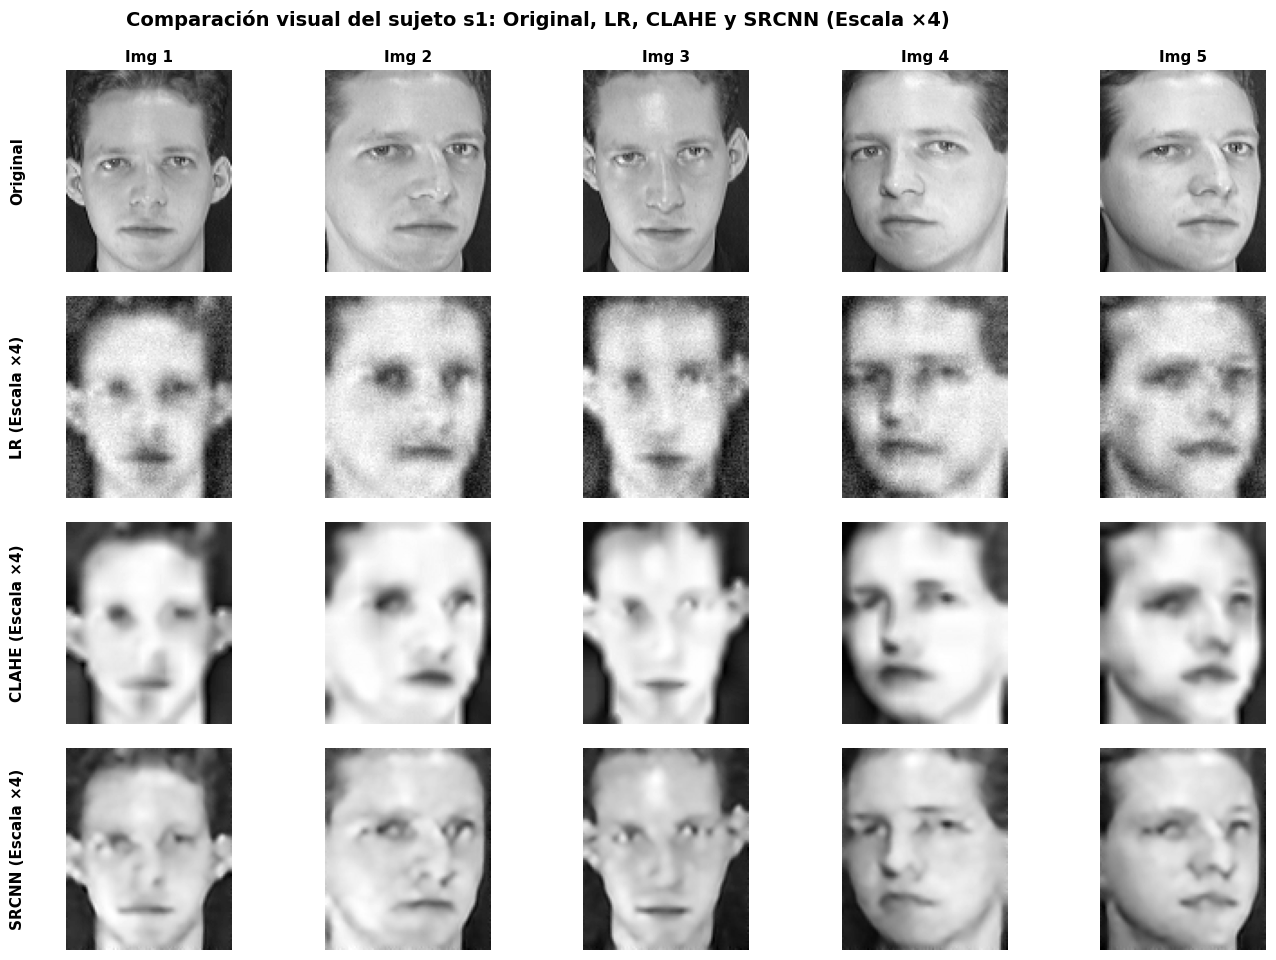

In [17]:
mostrar_comparacion(
    RUTAS_X4,
    ETIQUETAS_X4,
    archivos,
    "Comparación visual del sujeto s1: Original, LR, CLAHE y SRCNN (Escala ×4)"
)